# 05 – Model Inference & Prediction Demo

This notebook demonstrates how to use our trained expense category model
for **inference** on new transactions.

We will:

1. Load the tuned model and scaler saved in `models/`.
2. Load the processed transaction dataset.
3. Rebuild the numeric feature matrix (same schema as training).
4. Evaluate model performance (accuracy, classification report, confusion matrix).
5. Show example predictions on random transactions.

This notebook is intended for **demo purposes** in the final project presentation
(Build Models section), while a separate Gradio app will be used for deployment.

In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- allow imports from parent directory ---
import sys
sys.path.append("..")

import model_predict as mp   # our helper script

In [12]:
# 1. Load trained artifacts
model, scaler = mp.load_artifacts()

print("Loaded model type:", type(model))
print("Loaded scaler type:", type(scaler))
print("Label classes:", mp.LABEL_CLASSES)

Loaded model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Loaded scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>
Label classes: ['Bills', 'DiningOut', 'Education', 'Entertainment', 'Groceries', 'Healthcare', 'Miscellaneous', 'PersonalCare', 'Shopping', 'Transport', 'Travel', 'Utilities']


In [14]:
# 2. Load processed long-format transactions
data_path = mp.BASE_DIR / "data" / "processed" / "transactions_long.csv"
print("Data path:", data_path)

df = pd.read_csv(data_path)
df.head()

Data path: /workspaces/ari510-expense-categorization/data/processed/transactions_long.csv


,transaction_id,user_id,date,vendor,description,amount,payment_method,city,state,category
0,1,11,2023-05-10,DiningOut Store 041,"DiningOut spend at DiningOut Store 041, total ...",34.75,Digital Wallet,San Francisco,CA,DiningOut
1,2,2,2024-03-02,Healthcare Store 129,Card purchase at Healthcare Store 129 for 151....,151.75,Cash,Detroit,MI,Healthcare
2,3,51,2023-08-30,BP,Card purchase at BP for 78.98 USD (Transport),78.98,Debit Card,Austin,TX,Transport
3,4,55,2024-02-29,Hulu,"Mobile app payment at Hulu, Entertainment, 22.20",22.20,Credit Card,San Francisco,CA,Entertainment
4,5,49,2024-07-26,Miscellaneous Store 081,"Groceries spend at Miscellaneous Store 081, to...",39.38,Debit Card,Detroit,MI,Groceries


In [15]:
# 3. Rebuild numeric feature matrix using the same logic as training
df_num = mp._build_feature_matrix(df)  # yes, we're intentionally using the "private" helper

# Align indices so we can join back to the true category labels
df_num["__row_index__"] = df_num.index

df_merged = df_num.merge(
    df[["category"]],
    left_on="__row_index__",
    right_index=True,
    how="left",
)

X = df_merged.drop(columns=["__row_index__", "category"])
y_true = df_merged["category"]

print("Feature matrix shape:", X.shape)
print("Example feature columns:", list(X.columns)[:10])

Feature matrix shape: (10000, 2)
Example feature columns: ['transaction_id', 'amount']


In [16]:
# 4. Strict feature alignment + scaling + predictions

# Columns used during training
TRAIN_COLS = list(scaler.feature_names_in_)

# Drop ANY columns not used in training
X_aligned = X[TRAIN_COLS].copy()

print("Shape after strict alignment:", X_aligned.shape)

# Scale
X_scaled = scaler.transform(X_aligned)

# Predict
y_pred_idx = model.predict(X_scaled)
y_pred = np.array([mp.LABEL_CLASSES[int(i)] for i in y_pred_idx])

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall accuracy on processed dataset: {acc:.3f}")

Shape after strict alignment: (10000, 1)
Overall accuracy on processed dataset: 0.406


In [17]:
# 5. Detailed per-class metrics
print("Classification report (string labels):")
print(classification_report(y_true, y_pred, target_names=mp.LABEL_CLASSES))

Classification report (string labels):
               precision    recall  f1-score   support

        Bills       0.51      0.48      0.49       631
    DiningOut       0.34      0.87      0.49      1382
    Education       0.71      0.17      0.27       281
Entertainment       0.61      0.11      0.19       750
    Groceries       0.38      0.69      0.48      1754
   Healthcare       0.50      0.21      0.30       544
Miscellaneous       0.65      0.08      0.14       693
 PersonalCare       0.62      0.02      0.04       478
     Shopping       0.51      0.23      0.31      1219
    Transport       0.40      0.32      0.36      1048
       Travel       0.67      0.53      0.59       543
    Utilities       0.51      0.22      0.31       677

     accuracy                           0.41     10000
    macro avg       0.53      0.33      0.33     10000
 weighted avg       0.49      0.41      0.36     10000



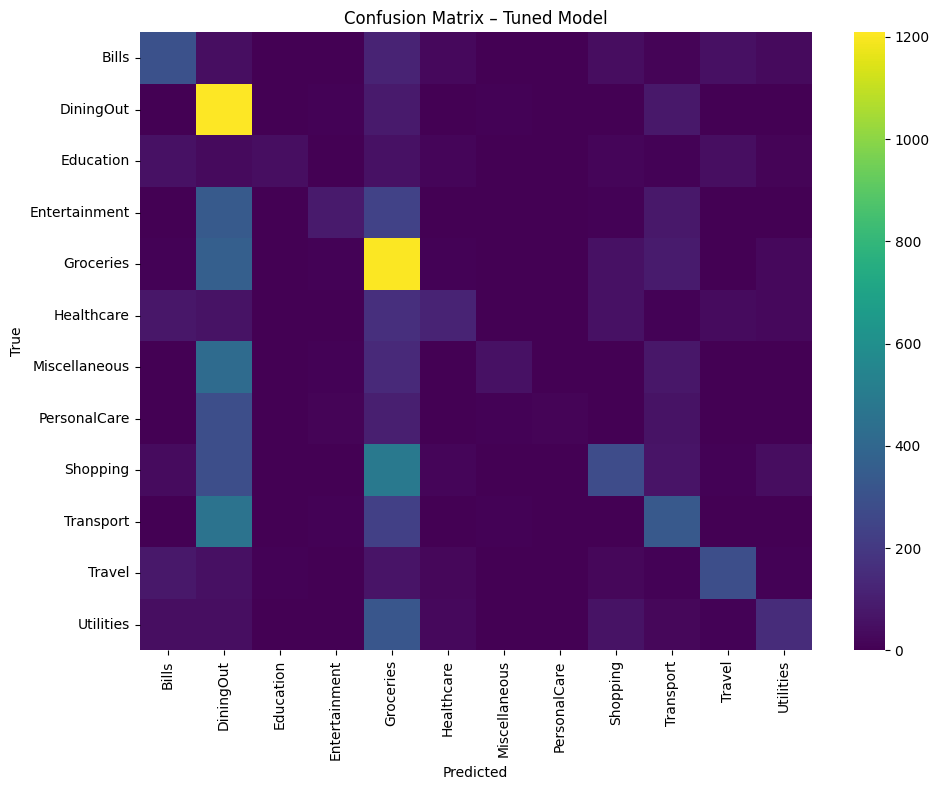

In [18]:
# 6. Confusion matrix heatmap for demo
cm = confusion_matrix(y_true, y_pred, labels=mp.LABEL_CLASSES)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=False,
    cmap="viridis",
    xticklabels=mp.LABEL_CLASSES,
    yticklabels=mp.LABEL_CLASSES,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Tuned Model")
plt.tight_layout()
plt.show()

In [19]:
# 7. Show a few random rows: true vs predicted
np.random.seed(42)

sample_idx = np.random.choice(len(X), size=5, replace=False)

print("=== Example predictions on random transactions ===")
for i in sample_idx:
    true_label = y_true.iloc[i]
    pred_label = y_pred[i]
    amount = df.loc[i, "amount"] if "amount" in df.columns else "N/A"
    vendor = df.loc[i, "vendor"] if "vendor" in df.columns else "N/A"

    print(
        f"Row {i:6d} | vendor={str(vendor)[:20]:20s} | amount={amount:>8} "
        f"| true = {true_label:12s} | predicted = {pred_label:12s}"
    )

=== Example predictions on random transactions ===
Row   6252 | vendor=Dental Clinic        | amount=   289.5 | true = Healthcare   | predicted = Bills       
Row   4684 | vendor=Utilities Store 165  | amount=   74.75 | true = Utilities    | predicted = Groceries   
Row   1731 | vendor=Miscellaneous Store  | amount=   39.67 | true = DiningOut    | predicted = DiningOut   
Row   4742 | vendor=Utilities Store 020  | amount=   64.74 | true = Shopping     | predicted = Groceries   
Row   4521 | vendor=PersonalCare Store 1 | amount=   20.43 | true = PersonalCare | predicted = DiningOut   
